In [1]:
import polars as pl
import catboost as cb
import os

path_train = os.path.join(os.getcwd(), "..", "data","train_main_features.parquet")
path_test = os.path.join(os.getcwd(),"..","data","test_main_features.parquet")
path_target = os.path.join(os.getcwd(),"..","data","train_target.parquet")
train = pl.read_parquet(path_train)
test = pl.read_parquet(path_test)
target = pl.read_parquet(path_target)

print(train.head(5))

target_columns = [c for c in target.columns if c != "customer_id"]


shape: (5, 200)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ customer_ ┆ cat_featu ┆ cat_featu ┆ cat_featu ┆ … ┆ num_featu ┆ num_featu ┆ num_featu ┆ num_feat │
│ id        ┆ re_1      ┆ re_2      ┆ re_3      ┆   ┆ re_129    ┆ re_130    ┆ re_131    ┆ ure_132  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ i32       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1000001   ┆ 1.0       ┆ 0.0       ┆ 2.0       ┆ … ┆ -0.107666 ┆ -0.418616 ┆ null      ┆ null     │
│ 1000002   ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ -0.170724 ┆ -0.805771 ┆ -0.397803 ┆ -0.37373 │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 4        │
│ 1000003   ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ -0.170724 ┆ -0.602005

In [2]:
os.environ['USER'] = "Daniil Krovyakov"

In [3]:
test = pl.read_parquet(path_test)
target = pl.read_parquet(path_target)

print(train.head(5))

target_columns = [c for c in target.columns if c != "customer_id"]


shape: (5, 200)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ customer_ ┆ cat_featu ┆ cat_featu ┆ cat_featu ┆ … ┆ num_featu ┆ num_featu ┆ num_featu ┆ num_feat │
│ id        ┆ re_1      ┆ re_2      ┆ re_3      ┆   ┆ re_129    ┆ re_130    ┆ re_131    ┆ ure_132  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ i32       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1000001   ┆ 1.0       ┆ 0.0       ┆ 2.0       ┆ … ┆ -0.107666 ┆ -0.418616 ┆ null      ┆ null     │
│ 1000002   ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ -0.170724 ┆ -0.805771 ┆ -0.397803 ┆ -0.37373 │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 4        │
│ 1000003   ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ -0.170724 ┆ -0.602005

In [4]:
target_summ = []
for c in target_columns:
    vals = target.select(pl.col(c).drop_nulls().unique().sort()).to_series().to_list()
    target_summ.append({
        "target": c,
        "n_unique": len(vals),
        "unique_values_preview": vals[:10]
    })

print(pl.DataFrame(target_summ))

shape: (41, 3)
┌─────────────┬──────────┬───────────────────────┐
│ target      ┆ n_unique ┆ unique_values_preview │
│ ---         ┆ ---      ┆ ---                   │
│ str         ┆ i64      ┆ list[f64]             │
╞═════════════╪══════════╪═══════════════════════╡
│ target_1_1  ┆ 2        ┆ [0.0, 1.0]            │
│ target_1_2  ┆ 2        ┆ [0.0, 1.0]            │
│ target_1_3  ┆ 2        ┆ [0.0, 1.0]            │
│ target_1_4  ┆ 2        ┆ [0.0, 1.0]            │
│ target_1_5  ┆ 2        ┆ [0.0, 1.0]            │
│ …           ┆ …        ┆ …                     │
│ target_9_5  ┆ 2        ┆ [0.0, 1.0]            │
│ target_9_6  ┆ 2        ┆ [0.0, 1.0]            │
│ target_9_7  ┆ 2        ┆ [0.0, 1.0]            │
│ target_9_8  ┆ 2        ┆ [0.0, 1.0]            │
│ target_10_1 ┆ 2        ┆ [0.0, 1.0]            │
└─────────────┴──────────┴───────────────────────┘


In [5]:
app = []
for c in train.columns:
    if c.startswith("n"):
        tr_sl_max = train.select(
            pl.col(c).max()
        ).item()
        tr_sl_min = train.select(
            pl.col(c).min()
        ).item()
        app.append({
            "max_value": tr_sl_max,
            "min_value": tr_sl_min,
            "column": c
        })
max_val = max(x["max_value"] for x in app)
min_val = min(x["min_value"] for x in app)
print(max_val, min_val)

1440.2291939697725 -10.039640917881606


In [6]:
for c in train.columns:
    exists = train.select((pl.col(c) == 2141.0).any()).item()
    if exists:
        print(c)


cat_feature_39


In [7]:

print(target.select(
    pl.col("target_9_8")
    .filter((pl.col("target_9_8") != 0.0) & (pl.col("target_9_8") != 1.0))
    .unique()
    .sort()
    )
)

shape: (0, 1)
┌────────────┐
│ target_9_8 │
│ ---        │
│ f64        │
╞════════════╡
└────────────┘


In [8]:
iqr_summary = []
for c in train.columns:
        if c.startswith("n"):
            q1 = train.select(pl.col(c).quantile(0.25)).item()
            q3 = train.select(pl.col(c).quantile(0.75)).item()
            if q1 is None or q3 is None:
                continue

            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            sort = train.select(
                ((pl.col(c) < lower) | (pl.col(c) > upper)).sum()
            ).item()

            iqr_summary.append({
                "column": c,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_bound": lower,
                "upper_bound": upper,
                "outer_count": sort
            })

iqr_df = pl.DataFrame(iqr_summary).sort("outer_count", descending=True)
print(iqr_df)

shape: (132, 7)
┌─────────────────┬───────────┬───────────┬──────────┬─────────────┬─────────────┬─────────────┐
│ column          ┆ q1        ┆ q3        ┆ iqr      ┆ lower_bound ┆ upper_bound ┆ outer_count │
│ ---             ┆ ---       ┆ ---       ┆ ---      ┆ ---         ┆ ---         ┆ ---         │
│ str             ┆ f64       ┆ f64       ┆ f64      ┆ f64         ┆ f64         ┆ i64         │
╞═════════════════╪═══════════╪═══════════╪══════════╪═════════════╪═════════════╪═════════════╡
│ num_feature_98  ┆ -0.004499 ┆ -0.004499 ┆ 0.0      ┆ -0.004499   ┆ -0.004499   ┆ 171499      │
│ num_feature_21  ┆ -0.140323 ┆ -0.124331 ┆ 0.015993 ┆ -0.164312   ┆ -0.100342   ┆ 137749      │
│ num_feature_67  ┆ -0.430568 ┆ -0.430568 ┆ 0.0      ┆ -0.430568   ┆ -0.430568   ┆ 123662      │
│ num_feature_76  ┆ -0.0279   ┆ -0.02019  ┆ 0.00771  ┆ -0.039465   ┆ -0.008625   ┆ 123463      │
│ num_feature_62  ┆ -0.025496 ┆ -0.017985 ┆ 0.007512 ┆ -0.036764   ┆ -0.006717   ┆ 114475      │
│ …           

In [9]:
train_new = train.select(
    pl.col("num_feature_98").n_unique()
)
print(train_new)
print(train["num_feature_98"].count())

shape: (1, 1)
┌────────────────┐
│ num_feature_98 │
│ ---            │
│ u32            │
╞════════════════╡
│ 859            │
└────────────────┘
746785


In [10]:
# app = []
# for c in train.columns:
#     tr = train.select(
#         (pl.col(c).is_null()).sum()
#     ).item()
#     if tr > 700000:
#         app.append({
#             "count": tr,
#             "column": c
#         })
# app_df = pl.DataFrame(app)

# cols_to_drop = app_df["column"].to_list()
# train_without_extra = train.clone().drop(cols_to_drop)


# print(train_without_extra.shape)

In [11]:
#find rows with count Nan more than 0.95
clear_train =train.select(pl.exclude("customer_id"))
n_rows = clear_train.height
nan_info = []
for c in clear_train.columns:
    len_nun = clear_train.select((pl.col(c).is_null()).sum().sort()).item()
    nan_info.append({
        "column": c,
        "count Nan": len_nun
    })
stats = pl.DataFrame(nan_info)

stats = stats.with_columns(
    (pl.col("count Nan") / n_rows).alias("null_ratio")
).sort("null_ratio", descending=True)

#print(stats.head(20))

threshold = 0.95

cols_to_drop = (
    stats
    .filter(pl.col("null_ratio") > threshold)
    .get_column("column")
    .to_list()
)

train_without_extra = clear_train.drop(cols_to_drop)
print(train_without_extra.shape)


(750000, 181)


In [12]:
for c in train_without_extra.columns:
    if c.startswith("cat"):
        train_without_extra = train_without_extra.with_columns([
            pl.col(c).cast(pl.String).cast(pl.Categorical)
        ])

print(train_without_extra)

shape: (750_000, 181)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ cat_featu ┆ cat_featu ┆ cat_featu ┆ cat_featu ┆ … ┆ num_featu ┆ num_featu ┆ num_featu ┆ num_feat │
│ re_1      ┆ re_2      ┆ re_3      ┆ re_4      ┆   ┆ re_129    ┆ re_130    ┆ re_131    ┆ ure_132  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ cat       ┆ cat       ┆ cat       ┆ cat       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ 0.0       ┆ 2.0       ┆ 1.0       ┆ … ┆ -0.107666 ┆ -0.418616 ┆ null      ┆ null     │
│ 1.0       ┆ 0.0       ┆ 0.0       ┆ 1.0       ┆ … ┆ -0.170724 ┆ -0.805771 ┆ -0.397803 ┆ -0.37373 │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 4        │
│ 1.0       ┆ 0.0       ┆ 0.0       ┆ 1.0       ┆ … ┆ -0.170724 ┆ -0.

In [13]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier


X = train_without_extra.to_pandas()
y = target.drop("customer_id").to_pandas()
y = y["target_1_1"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size = 0.2, random_state= 42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

In [14]:
print(X_train.shape)
print(y_train.shape)

(450000, 181)
(450000,)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def show_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14)
    plt.show()

In [27]:
def save_roc_plot(fpr, tpr, path):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, label="ROC")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title("ROC Curve")
    ax.legend()
    fig.savefig(path)
    plt.close(fig)

In [21]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("ensemble_experiments")

2026/04/06 14:35:56 INFO mlflow.tracking.fluent: Experiment with name 'ensemble_experiments' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/Vagant/ML_flow_server/artefacts/302313038168288758', creation_time=1775471756474, experiment_id='302313038168288758', last_update_time=1775471756474, lifecycle_stage='active', name='ensemble_experiments', tags={}>

In [ ]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.model_selection import cross_val_predict

cat_features = [x for x in train_without_extra.columns if x.startswith("cat")]

def experiment_ensemble(run_name: str, iteration_catboost: int=1000, learning_rate_catboost: float = 0.03,iteration_xgboost: int=500, learning_rate_xgboost: float = 0.03):
    with mlflow.start_run(run_name=run_name):

        mlflow.log_param("iteration_catboost", iteration_catboost)
        mlflow.log_param("iteration_xgboost", iteration_xgboost)
        mlflow.log_param("learning_rate_catboost", learning_rate_catboost)
        mlflow.log_param("learning_rate_xgboost", learning_rate_xgboost)

        mlflow.log_params({
            "ensemble_strategy": "weighted_average",
            "catboost_weight": 0.2,
            "xgboost_weight": 0.8
        })

        catboost = CatBoostClassifier(
            iterations=iteration_catboost,
            learning_rate=learning_rate_catboost,
            depth=6,
            cat_features=cat_features,
            loss_function='Logloss',
            verbose=50,
            l2_leaf_reg = 3,
            eval_metric='AUC',
            task_type='GPU',
            early_stopping_rounds=100,
            random_state=42
        )

        xgboost = XGBClassifier(
            n_estimators=iteration_xgboost,
            learning_rate=learning_rate_xgboost,
            max_depth=6,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective='binary:logistic',
            eval_metric='auc',
            random_state=42,
            tree_method='hist',
            enable_categorical=True,
            early_stopping_rounds=100
        )

        catboost.fit(X_train, y_train, eval_set=(X_valid, y_valid))
        pred1 = catboost.predict_proba(X_test)[:, 1]

        # pred1 = catboost.predict(X_test)
        # cm = confusion_matrix(y_test, pred1)

        # show_confusion_matrix(cm)
        xgboost.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=100)
        pred2 = xgboost.predict_proba(X_test)[:, 1]

        final_pred = 0.2 * pred1 + 0.8 * pred2

        fpr_ensembleBoost, tpr_ensembleBoost, threshold_ensembleBoost = roc_curve(y_test, final_pred)
        save_roc_plot(fpr_ensembleBoost, tpr_ensembleBoost, "roc_auc.png")

        mlflow.log_artifact("roc_auc.png")

        result_auc = roc_auc_score(y_test, final_pred)
        mlflow.log_metric("AUC_cat_xgb", result_auc)

        mlflow.catboost.log_model(catboost, "catboost_model")   
        mlflow.xgboost.log_model(xgboost, "xgboost_model")
        



Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7524652	best: 0.7524652 (0)	total: 697ms	remaining: 34m 48s
50:	test: 0.8080572	best: 0.8082546 (49)	total: 7.48s	remaining: 7m 12s
100:	test: 0.8343251	best: 0.8343251 (100)	total: 14.2s	remaining: 6m 48s
150:	test: 0.8469081	best: 0.8469081 (150)	total: 20.9s	remaining: 6m 33s
200:	test: 0.8538028	best: 0.8538028 (200)	total: 29.9s	remaining: 6m 56s
250:	test: 0.8587415	best: 0.8587501 (249)	total: 36.7s	remaining: 6m 41s
300:	test: 0.8618653	best: 0.8618653 (300)	total: 43.4s	remaining: 6m 29s
350:	test: 0.8642074	best: 0.8642074 (350)	total: 50s	remaining: 6m 17s
400:	test: 0.8660030	best: 0.8660030 (400)	total: 56.6s	remaining: 6m 6s
450:	test: 0.8671195	best: 0.8671195 (450)	total: 1m 3s	remaining: 6m
500:	test: 0.8680120	best: 0.8680120 (500)	total: 1m 10s	remaining: 5m 50s
550:	test: 0.8691029	best: 0.8691029 (550)	total: 1m 16s	remaining: 5m 41s
600:	test: 0.8698749	best: 0.8698749 (600)	total: 1m 23s	remaining: 5m 32s
650:	test: 0.8704279	best: 0.8704454 (649)	tota

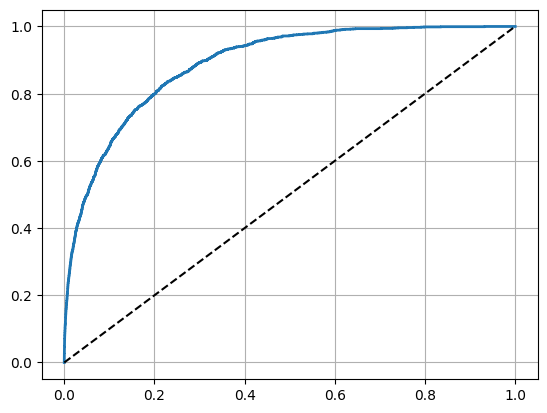

2026/04/06 14:48:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/06 14:48:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
c:\Users\Vagant\Desktop\Data_Fusion_2026\.venv\Lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [14:48:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
2026/04/06 14:48:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/04/06 14:48:37 WARNING mlflow.models.model: Model logged without a signature and input example. Pl

🏃 View run ensemble_catboost_xgboost at: http://127.0.0.1:5000/#/experiments/302313038168288758/runs/23afa2c9e04f48858a690fa62691b3f0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/302313038168288758


<Figure size 640x480 with 0 Axes>

In [ ]:
iteration_catboost = 5000
iteration_xgboost = 500
learning_rate = 0.03
experiment_ensemble("ensemble_catboost_xgboost",iteration_catboost, learning_rate, iteration_xgboost, learning_rate)